# ML-06 — Signal Audit: Do the Flags Hold?

This audit uses only the September 2025–March 2026 training anchors. It asks whether safe, pre-decision signals have a measured directional relationship with next-month decline. The comparisons are descriptive rather than causal, and validation plus the May→June sealed test remain outside this audit.

## 1. Distributions, missingness, and monthly base rates

Exposure and momentum are heavy-tailed, so the audit uses log exposure and quartile comparisons. Missingness is reported explicitly; no unavailable GA4 or position measurement is silently converted into ordinary zero performance.

mkdir -p failed for path C:\Users\hasan\AppData\Local\matplotlib: [WinError 5] Access is denied: 'C:\\Users\\hasan\\AppData\\Local\\matplotlib'


Matplotlib created a temporary cache directory at C:\Users\hasan\AppData\Local\Temp\matplotlib-1p1fo1ma because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


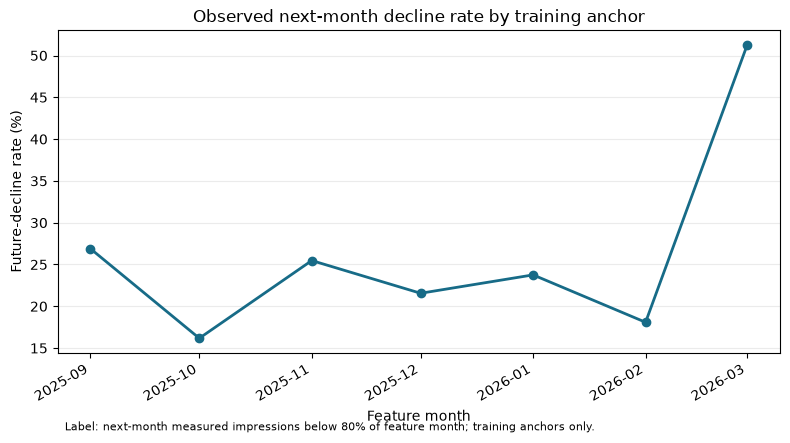

Training examples: 341,546; clients: 41; observed base rate: 29.3%


,count,mean,std,25%,50%,75%,missing_share
log_impressions,341546.0,6.782624,1.355384,5.683580,6.637258,7.731931,0.000000
impression_momentum,322210.0,5.552912,85.080392,0.959116,1.372255,2.166113,0.056613
avg_position,341542.0,12.036435,13.206205,4.346939,7.139482,14.005804,0.000012
active_days,341546.0,29.492068,2.179584,28.000000,30.000000,31.000000,0.000000
content_age_days,341546.0,183.213473,105.049115,95.000000,170.000000,256.000000,0.000000
ctr,341546.0,0.002957,0.004627,0.000000,0.001562,0.004085,0.000000
gsc_available_days,341546.0,29.492068,2.179584,28.000000,30.000000,31.000000,0.000000
ga4_available_days,341546.0,2.053261,4.842683,0.000000,0.000000,1.000000,0.000000
engaged_sessions,106394.0,0.761114,3.206511,0.000000,0.000000,1.000000,0.688493


,month,size,mean
0,2025-09-01,18684,0.268893
1,2025-10-01,26012,0.161771
2,2025-11-01,35384,0.254720
3,2025-12-01,49277,0.215598
4,2026-01-01,58778,0.237572
5,2026-02-01,64470,0.180890
6,2026-03-01,88941,0.512542


In [1]:
from pathlib import Path
import json
import sys

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
while not (ROOT / 'work' / 'scripts').exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
cache = ROOT / 'work' / 'outputs' / 'model_examples.parquet'
figures = ROOT / 'work' / 'figures'
figures.mkdir(parents=True, exist_ok=True)
con = duckdb.connect()
train = con.execute(
    "SELECT * FROM read_parquet(?) WHERE month BETWEEN DATE '2025-09-01' AND DATE '2026-03-01'",
    [str(cache)],
).df()
train['log_impressions'] = np.log1p(train['impressions'])
signals = ['log_impressions', 'impression_momentum', 'avg_position', 'active_days', 'content_age_days', 'ctr', 'gsc_available_days', 'ga4_available_days', 'engaged_sessions']
distribution = train[signals].describe(percentiles=[.25, .5, .75]).T[['count', 'mean', 'std', '25%', '50%', '75%']]
distribution['missing_share'] = train[signals].isna().mean()
base_by_month = train.groupby('month', observed=True)['future_decline'].agg(['size', 'mean']).reset_index()
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(base_by_month['month'], 100 * base_by_month['mean'], marker='o', color='#176B87', linewidth=2)
ax.set(title='Observed next-month decline rate by training anchor', xlabel='Feature month', ylabel='Future-decline rate (%)')
ax.grid(axis='y', alpha=.25)
ax.text(.01, -.24, 'Label: next-month measured impressions below 80% of feature month; training anchors only.', transform=ax.transAxes, fontsize=8)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(figures / 'base_rate_by_month.png', dpi=180, bbox_inches='tight')
plt.show()
print(f'Training examples: {len(train):,}; clients: {train.client_hash_id.nunique():,}; observed base rate: {train.future_decline.mean():.1%}')
display(distribution)
display(base_by_month)

## 2. Three named signal tests

Each mini-test compares the observed label rate in the highest and lowest measured quartiles on the same training sample. The effect is a percentage-point difference, not a causal lift.

1. **Exposure test:** Are highly visible items more likely to show a material next-month fall?
2. **Momentum test:** Does the current/prior impression ratio separate future risk? A non-monotonic result is kept only as a nonlinear input.
3. **Position test:** Do worse measured positions carry more directional decline risk?

In [2]:
def quartile_test(frame, signal, label='future_decline'):
    measured = frame[[signal, label]].dropna().copy()
    measured['quartile'] = pd.qcut(measured[signal], 4, labels=False, duplicates='drop')
    grouped = measured.groupby('quartile', observed=True)[label].agg(['size', 'mean'])
    low, high = grouped.iloc[0], grouped.iloc[-1]
    return {
        'signal': signal, 'sample_size': int(len(measured)),
        'low_quartile_rate': float(low['mean']), 'high_quartile_rate': float(high['mean']),
        'effect_percentage_points': float(100 * (high['mean'] - low['mean'])),
    }

named_tests = [quartile_test(train, name) for name in ['log_impressions', 'impression_momentum', 'avg_position']]
named_tests[0].update(verdict='keep', practical_implication='Exposure helps prioritize impact, but is not sufficient alone.')
named_tests[1].update(verdict='keep', practical_implication='The U-shaped quartile pattern requires a nonlinear model or explicit bands.')
named_tests[2].update(verdict='keep', practical_implication='Position adds measured directional context when the validity flag is true.')
test_table = pd.DataFrame(named_tests)
display(test_table)
for row in named_tests:
    print(f"{row['signal']}: n={row['sample_size']:,}, high-minus-low={row['effect_percentage_points']:+.1f} pp → {row['verdict'].upper()}")

,signal,sample_size,low_quartile_rate,high_quartile_rate,effect_percentage_points,verdict,practical_implication
0,log_impressions,341546,0.267181,0.313213,4.603183,keep,"Exposure helps prioritize impact, but is not s..."
1,impression_momentum,322210,0.332601,0.315643,-1.695778,keep,The U-shaped quartile pattern requires a nonli...
2,avg_position,341542,0.268858,0.331565,6.270664,keep,Position adds measured directional context whe...


log_impressions: n=341,546, high-minus-low=+4.6 pp → KEEP
impression_momentum: n=322,210, high-minus-low=-1.7 pp → KEEP
avg_position: n=341,542, high-minus-low=+6.3 pp → KEEP


## 3. Flag-linked coverage test

Active-day and analytics-availability fields resemble operational eligibility flags. Their observed label rates differ, but they are also mechanically tied to month length, data starts, and measurement access. I therefore keep active days as **context only** and **exclude** raw availability-day counts from the predictive model; they remain mandatory quality filters.

In [3]:
coverage_tests = [quartile_test(train, name) for name in ['active_days', 'gsc_available_days', 'ga4_available_days']]
coverage_tests[0].update(verdict='context only', practical_implication='Useful for review context, but confounded with calendar and coverage.')
coverage_tests[1].update(verdict='exclude', practical_implication='Use as an eligibility check, not a model signal.')
coverage_tests[2].update(verdict='exclude', practical_implication='Reflects access/measurement availability rather than content quality.')
coverage_table = pd.DataFrame(coverage_tests)
display(coverage_table)
print('Flag-linked verdict: availability supports filtering and monitoring, not an editorial performance claim.')

,signal,sample_size,low_quartile_rate,high_quartile_rate,effect_percentage_points,verdict,practical_implication
0,active_days,341546,0.218409,0.334870,11.646064,context only,"Useful for review context, but confounded with..."
1,gsc_available_days,341546,0.218409,0.334870,11.646064,exclude,"Use as an eligibility check, not a model signal."
2,ga4_available_days,341546,0.269440,0.365964,9.652414,exclude,Reflects access/measurement availability rathe...


Flag-linked verdict: availability supports filtering and monitoring, not an editorial performance claim.


## 4. Complete verdicts and practical meaning

The evidence supports a multivariable ranking rather than a single fixed threshold. Exposure, momentum, valid position, age, and CTR are retained; active days are reviewer context; availability and sparse engagement are excluded from prediction. A content team should use the result to order human review, then inspect page intent and business context before taking action.

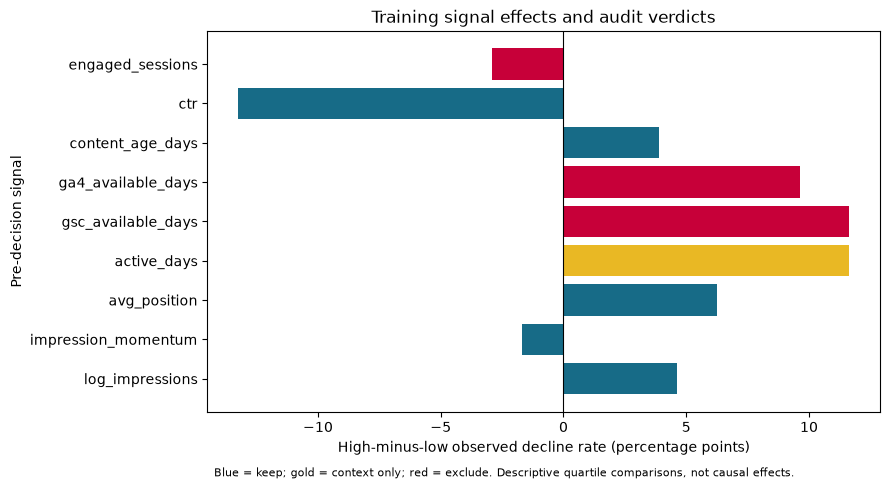

,signal,sample_size,effect_percentage_points,verdict,practical_implication
0,log_impressions,341546,4.603183,keep,"Exposure helps prioritize impact, but is not s..."
1,impression_momentum,322210,-1.695778,keep,The U-shaped quartile pattern requires a nonli...
2,avg_position,341542,6.270664,keep,Position adds measured directional context whe...
3,active_days,341546,11.646064,context only,"Useful for review context, but confounded with..."
4,gsc_available_days,341546,11.646064,exclude,"Use as an eligibility check, not a model signal."
5,ga4_available_days,341546,9.652414,exclude,Reflects access/measurement availability rathe...
6,content_age_days,341546,3.877432,keep,Age adds established-content context; effect r...
7,ctr,341546,-13.261865,keep,CTR separates measured risk but does not diagn...
8,engaged_sessions,106394,-2.914778,exclude,Sparse GA4 coverage would narrow and bias the ...


Audit complete: every signal has a sample size, effect magnitude, explicit verdict, and practical implication.


In [4]:
other_tests = [quartile_test(train, name) for name in ['content_age_days', 'ctr', 'engaged_sessions']]
other_tests[0].update(verdict='keep', practical_implication='Age adds established-content context; effect remains observational.')
other_tests[1].update(verdict='keep', practical_implication='CTR separates measured risk but does not diagnose a metadata cause.')
other_tests[2].update(verdict='exclude', practical_implication='Sparse GA4 coverage would narrow and bias the usable queue.')
audit_rows = named_tests + coverage_tests + other_tests
audit = {
    'scope': 'training anchors 2025-09 through 2026-03 only',
    'training_rows': int(len(train)),
    'training_clients': int(train.client_hash_id.nunique()),
    'observed_base_rate': float(train.future_decline.mean()),
    'effect_definition': 'high-quartile minus low-quartile observed future-decline rate, percentage points',
    'signals': audit_rows,
}
(ROOT / 'work' / 'outputs' / 'signal_audit.json').write_text(json.dumps(audit, indent=2) + '\n', encoding='utf-8')
effect_frame = pd.DataFrame(audit_rows)
colors = effect_frame['verdict'].map({'keep': '#176B87', 'context only': '#E9B824', 'exclude': '#C70039'})
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(effect_frame['signal'], effect_frame['effect_percentage_points'], color=colors)
ax.axvline(0, color='black', linewidth=.8)
ax.set(title='Training signal effects and audit verdicts', xlabel='High-minus-low observed decline rate (percentage points)', ylabel='Pre-decision signal')
ax.text(.01, -.17, 'Blue = keep; gold = context only; red = exclude. Descriptive quartile comparisons, not causal effects.', transform=ax.transAxes, fontsize=8)
fig.tight_layout()
fig.savefig(figures / 'signal_effects.png', dpi=180, bbox_inches='tight')
plt.show()
display(effect_frame[['signal', 'sample_size', 'effect_percentage_points', 'verdict', 'practical_implication']])
assert {'keep', 'context only', 'exclude'}.issubset(set(effect_frame['verdict']))
print('Audit complete: every signal has a sample size, effect magnitude, explicit verdict, and practical implication.')

## Self-check

- [x] Distributions, missingness, client coverage, and monthly base rates are visible.
- [x] Three named signal tests include samples, effects, verdicts, and implications.
- [x] Keep, context only, and exclude decisions are explicit.
- [x] Validation and sealed labels were not used.
- [x] No client-identifying fields are displayed; claims remain observed and directional.